## 1. Load and Parse the Dataset

The dataset is provided in `.dat` format. Each measurement contains:
- a gas label
- a concentration value
- 128 sensor-derived features stored as `feature:value` pairs

The raw records are parsed into a Pandas DataFrame for analysis.

In [155]:
file_path = "../data/batch1.dat"

with open(file_path, "r") as f:
    lines = f.readlines()

print("Number of measurements:", len(lines))

Number of measurements: 445


In [163]:
import pandas as pd

data = []

for line in lines:
    parts = line.strip().split()

    # First part contains label and concentration
    label, concentration = parts[0].split(";")

    # Remaining 128 parts are features
    features = {}

    for item in parts[1:]:
        feature_number, value = item.split(":")
        features[f"feature_{feature_number}"] = float(value)

    row = {
        "label": int(label),
        "concentration": float(concentration),
        **features
    }

    data.append(row)

df = pd.DataFrame(data)

print("Rows:",df.shape[0],"\nColumns:",df.shape[1])
df.head()

Rows: 445 
Columns: 130


,label,concentration,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128
0,1,10.0,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,-4.847512,...,-1.071137,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529
1,1,20.0,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,-7.518333,...,-1.530519,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225
2,1,30.0,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,-12.230939,...,-2.384784,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370
3,1,40.0,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,-11.921704,...,-2.607199,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957
4,1,50.0,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,-16.407848,...,-3.594763,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756


### Dataset Overview

The dataset contains measurements from six gas classes. The label distribution is checked before proceeding with further analysis.

In [166]:
df["label"].value_counts().sort_index()

label
1    90
2    98
3    83
4    30
5    70
6    74
Name: count, dtype: int64

In [170]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [172]:
df["concentration"].describe()

count     445.000000
mean      198.044944
std       224.189979
min         5.000000
25%        50.000000
50%       125.000000
75%       250.000000
max      1000.000000
Name: concentration, dtype: float64

## 2. Exploratory Data Analysis

Before building a classifier, we examine the class distribution, concentration levels, and how sensor-derived features vary across gas classes.

The goal is to identify patterns in the measurements and understand whether the gas classes show distinguishable feature distributions.

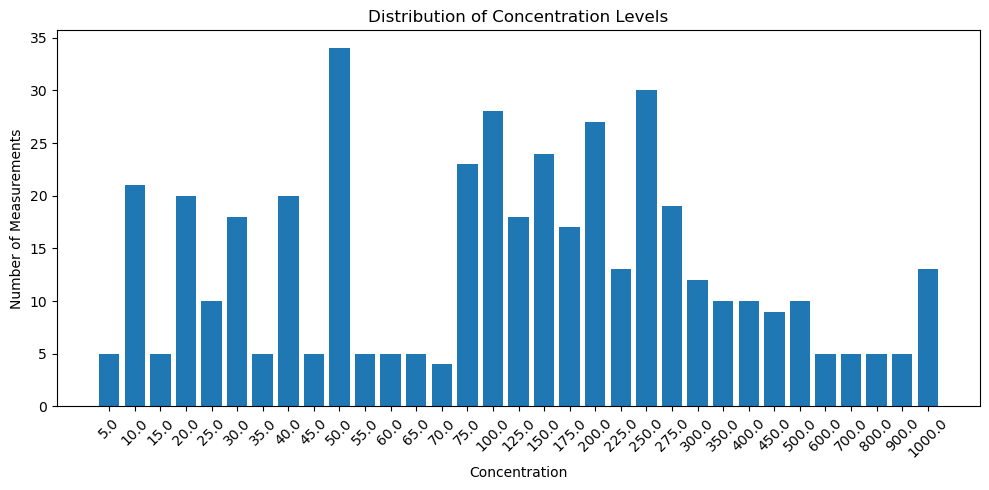

In [201]:
# 2.1 Concentration distribution
import matplotlib.pyplot as plt

concentration_counts = df["concentration"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(concentration_counts.index.astype(str), concentration_counts.values)

plt.xlabel("Concentration")
plt.ylabel("Number of Measurements")
plt.title("Distribution of Concentration Levels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [203]:
# 2.2 Gas class distribution
gas_names = {
    1: "Ethanol",
    2: "Ethylene",
    3: "Ammonia",
    4: "Acetaldehyde",
    5: "Acetone",
    6: "Toluene"
}

df["gas"] = df["label"].map(gas_names)

df[["label", "gas"]].drop_duplicates().sort_values("label")

,label,gas
0,1,Ethanol
84,2,Ethylene
172,3,Ammonia
271,4,Acetaldehyde
301,5,Acetone
371,6,Toluene


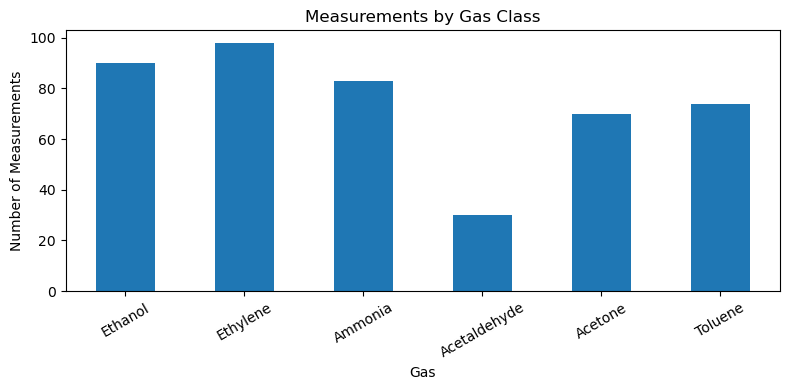

In [205]:
df["gas"].value_counts().reindex(gas_names.values()).plot(
    kind="bar",
    figsize=(8, 4)
)

plt.xlabel("Gas")
plt.ylabel("Number of Measurements")
plt.title("Measurements by Gas Class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

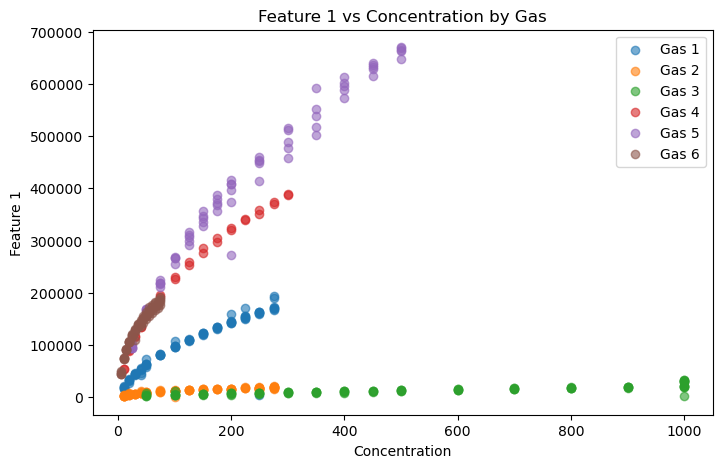

In [207]:
# 2.3 Feature 1 vs concentration
plt.figure(figsize=(8, 5))

for label in sorted(df["label"].unique()):
    subset = df[df["label"] == label]
    
    plt.scatter(
        subset["concentration"],
        subset["feature_1"],
        alpha=0.6,
        label=f"Gas {label}"
    )

plt.xlabel("Concentration")
plt.ylabel("Feature 1")
plt.title("Feature 1 vs Concentration by Gas")
plt.legend()

plt.show()

### Feature Correlation

The dataset contains 128 sensor-derived features. Correlation analysis is used to identify groups of features that show similar behavior and may contain redundant information.


In [214]:
# 2.4 Feature correlation
import numpy as np
feature_cols = [col for col in df.columns if col.startswith("feature_")]

correlation_matrix = df[feature_cols].corr()

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

top_correlations = (
    upper_triangle
    .stack()
    .abs()
    .sort_values(ascending=False)
)

top_correlations.head(10)

feature_35   feature_43     0.999658
feature_11   feature_67     0.999405
feature_33   feature_41     0.999307
feature_118  feature_126    0.999252
feature_34   feature_42     0.999250
feature_38   feature_46     0.999154
feature_9    feature_65     0.999070
feature_14   feature_70     0.999067
feature_9    feature_73     0.998968
feature_115  feature_123    0.998936
dtype: float64

## 3. Principal Component Analysis

Because the dataset contains 128 features with substantial correlation, Principal Component Analysis (PCA) is used to project the measurements into a lower-dimensional space for visualization.

PCA is used here for exploratory visualization and is not part of the final classification pipeline.


In [217]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[feature_cols]
y = df["label"]

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled_pca)

In [219]:
explained_variance = pca.explained_variance_ratio_

print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])
print("PC1 + PC2:", explained_variance[:2].sum())

PC1: 0.577600547791821
PC2: 0.2374082266874004
PC1 + PC2: 0.8150087744792214


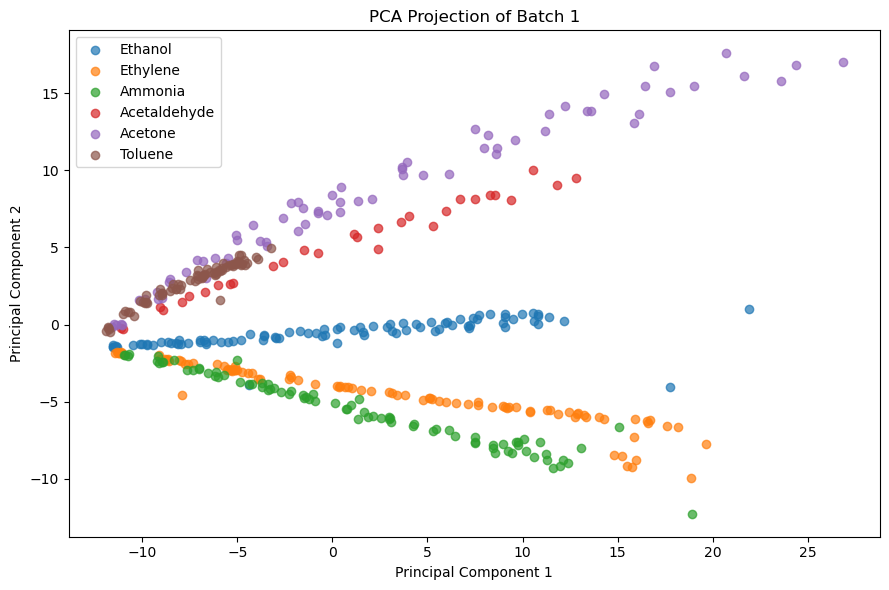

In [221]:
plt.figure(figsize=(9, 6))

for label in sorted(y.unique()):
    mask = y == label

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=gas_names[label],
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Batch 1")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Gas Classification

A Logistic Regression classifier is used as a baseline model for predicting the gas class from the 128 sensor-derived features.

The data is split into training and test sets before standardization. The scaler is fitted only on the training data to prevent information from the test set from influencing the model.


In [224]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[feature_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [226]:
# 4.2 Train the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [228]:
y_pred = model.predict(X_test_scaled)

accuracy = (y_pred == y_test).mean()

print(f"Test accuracy: {accuracy:.3%}")

Test accuracy: 95.506%


### Classification Performance

Accuracy provides an overall measure of correct predictions, while precision, recall, and F1-score show how well the model performs for each gas class.


In [231]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       0.95      0.95      0.95        20
           3       1.00      0.94      0.97        16
           4       1.00      0.67      0.80         6
           5       1.00      1.00      1.00        14
           6       0.88      1.00      0.94        15

    accuracy                           0.96        89
   macro avg       0.96      0.93      0.94        89
weighted avg       0.96      0.96      0.95        89



In [233]:
# 4.4 Confusion matrix
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {gas_names[i]}" for i in model.classes_],
    columns=[f"Predicted {gas_names[i]}" for i in model.classes_]
)

cm_df

,Predicted Ethanol,Predicted Ethylene,Predicted Ammonia,Predicted Acetaldehyde,Predicted Acetone,Predicted Toluene
Actual Ethanol,18,0,0,0,0,0
Actual Ethylene,1,19,0,0,0,0
Actual Ammonia,0,1,15,0,0,0
Actual Acetaldehyde,0,0,0,4,0,2
Actual Acetone,0,0,0,0,14,0
Actual Toluene,0,0,0,0,0,15


In [239]:
# Error-Analysis
mistakes = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

mistakes = mistakes[mistakes["actual"] != mistakes["predicted"]]

mistakes

,actual,predicted
172,3,2
290,4,6
271,4,6
261,2,1


In [241]:
mistakes["actual"] = mistakes["actual"].map(gas_names)
mistakes["predicted"] = mistakes["predicted"].map(gas_names)

mistakes

,actual,predicted
172,Ammonia,Ethylene
290,Acetaldehyde,Toluene
271,Acetaldehyde,Toluene
261,Ethylene,Ethanol


## 5. Generalization to an Unseen Batch

The classifier is trained on Batch 1 and evaluated on Batch 2 without retraining.

The same feature scaling learned from Batch 1 is applied to Batch 2. This allows us to test whether the relationships learned from one batch remain effective when the measurements come from a different batch.

In [248]:
file_path = "../data/batch2.dat"

with open(file_path, "r") as f:
    lines_batch2 = f.readlines()

data_batch2 = []

for line in lines_batch2:
    parts = line.strip().split()

    label, concentration = parts[0].split(";")

    features = {}

    for item in parts[1:]:
        feature_number, value = item.split(":")
        features[f"feature_{feature_number}"] = float(value)

    data_batch2.append({
        "label": int(label),
        "concentration": float(concentration),
        **features
    })

df_batch2 = pd.DataFrame(data_batch2)

print("Rows:", df_batch2.shape[0])
print("Columns:", df_batch2.shape[1])


Rows: 1244
Columns: 130


In [257]:
X_batch2 = df_batch2[feature_cols]
y_batch2 = df_batch2["label"]

X_batch2_scaled = scaler.transform(X_batch2)

batch2_pred = model.predict(X_batch2_scaled)

batch2_accuracy = (batch2_pred == y_batch2).mean()

print(f"Batch 2 accuracy: {batch2_accuracy:.3%}")

Batch 2 accuracy: 73.955%


In [252]:
print(classification_report(
    y_batch2,
    batch2_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.47      0.96      0.63       164
           2       0.99      0.93      0.96       334
           3       0.42      1.00      0.59       100
           4       0.00      0.00      0.00       109
           5       1.00      0.65      0.79       532
           6       0.50      1.00      0.67         5

    accuracy                           0.74      1244
   macro avg       0.56      0.76      0.61      1244
weighted avg       0.79      0.74      0.73      1244



In [254]:
cm_batch2 = confusion_matrix(
    y_batch2,
    batch2_pred,
    labels=model.classes_
)

cm_batch2_df = pd.DataFrame(
    cm_batch2,
    index=[f"Actual {gas_names[i]}" for i in model.classes_],
    columns=[f"Predicted {gas_names[i]}" for i in model.classes_]
)

cm_batch2_df

,Predicted Ethanol,Predicted Ethylene,Predicted Ammonia,Predicted Acetaldehyde,Predicted Acetone,Predicted Toluene
Actual Ethanol,158,4,2,0,0,0
Actual Ethylene,20,312,1,1,0,0
Actual Ammonia,0,0,100,0,0,0
Actual Acetaldehyde,108,0,0,0,0,1
Actual Acetone,49,0,134,0,345,4
Actual Toluene,0,0,0,0,0,5


### Batch 2 Result

Performance decreases compared with the within-Batch 1 evaluation. The confusion matrix shows that some gas classes become systematically harder to distinguish on the unseen batch, particularly Acetaldehyde.

This indicates that the feature relationships learned from Batch 1 do not fully generalize to a later batch. The result is consistent with batch-to-batch distribution changes relevant to sensor drift, although the accuracy drop alone does not establish that sensor drift is the only cause.

### Batch 3 Evaluation

Batch 3 is evaluated using the same model and scaler trained on Batch 1.

No retraining or refitting is performed on Batch 3. This keeps the evaluation focused on how well the Batch 1 feature relationships generalize to another unseen batch.

In [262]:
file_path = "../data/batch3.dat"

with open(file_path, "r") as f:
    lines_batch3 = f.readlines()

data_batch3 = []

for line in lines_batch3:
    parts = line.strip().split()

    label, concentration = parts[0].split(";")

    features = {}

    for item in parts[1:]:
        feature_number, value = item.split(":")
        features[f"feature_{feature_number}"] = float(value)

    data_batch3.append({
        "label": int(label),
        "concentration": float(concentration),
        **features
    })

df_batch3 = pd.DataFrame(data_batch3)

print("Rows:", df_batch3.shape[0])
print("Columns:", df_batch3.shape[1])

# df_batch3.head()

Rows: 1586
Columns: 130


In [264]:
X_batch3 = df_batch3[feature_cols]
y_batch3 = df_batch3["label"]

X_batch3_scaled = scaler.transform(X_batch3)

batch3_pred = model.predict(X_batch3_scaled)

batch3_accuracy = (batch3_pred == y_batch3).mean()

print(f"Batch 3 accuracy: {batch3_accuracy:.3%}")

Batch 3 accuracy: 69.357%


In [266]:
print(classification_report(
    y_batch3,
    batch3_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.52      0.97      0.67       365
           2       1.00      0.91      0.95       490
           3       0.60      0.88      0.71       216
           4       0.00      0.00      0.00       240
           5       1.00      0.41      0.58       275
           6       0.00      0.00      0.00         0

    accuracy                           0.69      1586
   macro avg       0.52      0.53      0.49      1586
weighted avg       0.68      0.69      0.65      1586



In [270]:
cm_batch3 = confusion_matrix(
    y_batch3,
    batch3_pred,
    labels=model.classes_
)

cm_batch3_df = pd.DataFrame(
    cm_batch3,
    index=[f"Actual {gas_names[i]}" for i in model.classes_],
    columns=[f"Predicted {gas_names[i]}" for i in model.classes_]
)

cm_batch3_df

,Predicted Ethanol,Predicted Ethylene,Predicted Ammonia,Predicted Acetaldehyde,Predicted Acetone,Predicted Toluene
Actual Ethanol,353,0,0,0,0,12
Actual Ethylene,45,445,0,0,0,0
Actual Ammonia,25,1,190,0,0,0
Actual Acetaldehyde,238,1,0,0,0,1
Actual Acetone,20,0,129,3,112,11
Actual Toluene,0,0,0,0,0,0


## Cross-Batch Results

The classifier performs strongly on a held-out subset of Batch 1, but performance decreases when the same model is applied to later unseen batches.

| Evaluation | Accuracy |
|---|---:|
| Batch 1 test split | 95.5% |
| Unseen Batch 2 | 74.0% |
| Unseen Batch 3 | 69.4% |

The decline indicates that the feature relationships learned from Batch 1 do not fully generalize across later batches. This demonstrates sensitivity to batch-to-batch distribution changes relevant to sensor drift.